Exploring the Link Between Personality Traits and Substance Use

Importing both necessary and custom modules

In [1]:
import sys
import pandas as pd
import plotnine as pn
import sklearn as sk
import numpy as np
import data_analysis
import data_reading
import matplotlib.pyplot as plt



Read in the data

In [2]:
data = data_reading.read_data("data/drug_consumption.csv")
human_readable_data = data_reading.convert_data(data)
human_readable_data = data_reading.convert_drug_usage_classifiers(human_readable_data)
df = human_readable_data
human_readable_data

,ID,Age,Gender,Education,Country,Ethnicity,Nscore,Escore,Oscore,Ascore,...,Ecstasy,Heroin,Ketamine,Legalh,LSD,Meth,Mushrooms,Nicotine,Semer,VSA
0,1,35-44,Female,Professional Certificate/Diploma,UK,Mixed-White/Asian,39.0,36.0,42.0,37.0,...,Never Used,Never Used,Never Used,Never Used,Never Used,Never Used,Never Used,Used in Last Decade,Never Used,Never Used
1,2,25-34,Male,Doctorate Degree,UK,White,29.0,52.0,55.0,48.0,...,Used in Last Month,Never Used,Used in Last Decade,Never Used,Used in Last Decade,Used in Last Year,Never Used,Used in Last Month,Never Used,Never Used
2,3,35-44,Male,Professional Certificate/Diploma,UK,White,31.0,45.0,40.0,32.0,...,Never Used,Never Used,Never Used,Never Used,Never Used,Never Used,Used over a Decade Ago,Never Used,Never Used,Never Used
3,4,18-24,Female,Master's Degree,UK,White,34.0,34.0,46.0,47.0,...,Never Used,Never Used,Used in Last Decade,Never Used,Never Used,Never Used,Never Used,Used in Last Decade,Never Used,Never Used
4,5,35-44,Female,Doctorate Degree,UK,White,43.0,28.0,43.0,41.0,...,Used over a Decade Ago,Never Used,Never Used,Used over a Decade Ago,Never Used,Never Used,Used in Last Decade,Used in Last Decade,Never Used,Never Used
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1880,1884,18-24,Female,"Some College, No Certificate/Degree",USA,White,25.0,51.0,57.0,48.0,...,Never Used,Never Used,Never Used,Used in Last Year,Used in Last Year,Never Used,Never Used,Never Used,Never Used,Used in Last Week
1881,1885,18-24,Male,"Some College, No Certificate/Degree",USA,White,33.0,51.0,50.0,48.0,...,Used in Last Decade,Never Used,Never Used,Used in Last Year,Used in Last Week,Used in Last Month,Used in Last Month,Used in Last Week,Never Used,Never Used
1882,1886,25-34,Female,University Degree,USA,White,47.0,30.0,37.0,31.0,...,Used in Last Month,Never Used,Used in Last Decade,Never Used,Used in Last Decade,Never Used,Used in Last Decade,Used in Last Day,Never Used,Never Used
1883,1887,18-24,Female,"Some College, No Certificate/Degree",USA,White,45.0,26.0,48.0,32.0,...,Used in Last Year,Never Used,Never Used,Used in Last Year,Used in Last Year,Never Used,Used in Last Year,Used in Last Month,Never Used,Never Used


Make a DataFrame useful for categorizing drugs

Nscore: Nscore is NEO-FFI-R Neuroticism. Neuroticism is one of the Big Five higher-order personality traits in the study of psychology. Individuals who score high on neuroticism are more likely than average to be moody and to experience such feelings as anxiety, worry, fear, anger, frustration, envy, jealousy, guilt, depressed mood, and loneliness.

EScore: Escore (Real) is NEO-FFI-R Extraversion. Extraversion is one of the five personality traits of the Big Five personality theory. It indicates how outgoing and social a person is. A person who scores high in extraversion on a personality test is the life of the party. They enjoy being with people, participating in social gatherings, and are full of energy. 

Oscore: Oscore (Real) is NEO-FFI-R Openness to experience. Openness is one of the five personality traits of the Big Five personality theory. It indicates how open-minded a person is. A person with a high level of openness to experience in a personality test enjoys trying new things. They are imaginative, curious, and open-minded. Individuals who are low in openness to experience would rather not try new things. They are close-minded, literal and enjoy having a routine.

Ascore: Ascore(Real) is NEO-FFI-R Agreeableness. Agreeableness is one of the five personality traits of the Big Five personality theory. A person with a high level of agreeableness in a personality test is usually warm, friendly, and tactful. They generally have an optimistic view of human nature and get along well with others.

Cscore: Cscore (Real) is NEO-FFI-R Conscientiousness. Conscientiousness is one of the five personality traits of the Big Five personality theory. A person scoring high in conscientiousness usually has a high level of self-discipline. These individuals prefer to follow a plan, rather than act spontaneously. Their methodic planning and perseverance usually makes them highly successful in their chosen occupation.

Impulsive: Impulsive (Real) is impulsiveness measured by BIS-11. In psychology, impulsivity (or impulsiveness) is a tendency to act on a whim, displaying behavior characterized by little or no forethought, reflection, or consideration of the consequences. If you describe someone as impulsive, you mean that they do things suddenly without thinking about them carefully first.

Sensation: SS(Real) is sensation seeing measured by ImpSS. Sensation is input about the physical world obtained by our sensory receptors, and perception is the process by which the brain selects, organizes, and interprets these sensations. In other words, senses are the physiological basis of perception.

In [3]:
# Bring data to a shape possible to be shown as a plot
drug_usage = data_analysis.get_columns_unique_value_counts(data[data_reading.DRUG_TYPES])
drug_usage = drug_usage.transpose().reset_index(names="Drug")
drug_usage = drug_usage.melt(id_vars="Drug", var_name="Usage", value_name="Amount")

# Replace NaN amounts with 0-s
drug_usage = drug_usage.fillna(0)

drug_usage

,Drug,Usage,Amount
0,Alcohol,CL0,34.0
1,Amphet,CL0,976.0
2,Amyl,CL0,1305.0
3,Benzos,CL0,1000.0
4,Caff,CL0,27.0
...,...,...,...
128,Meth,CL6,73.0
129,Mushrooms,CL6,4.0
130,Nicotine,CL6,610.0
131,Semer,CL6,0.0


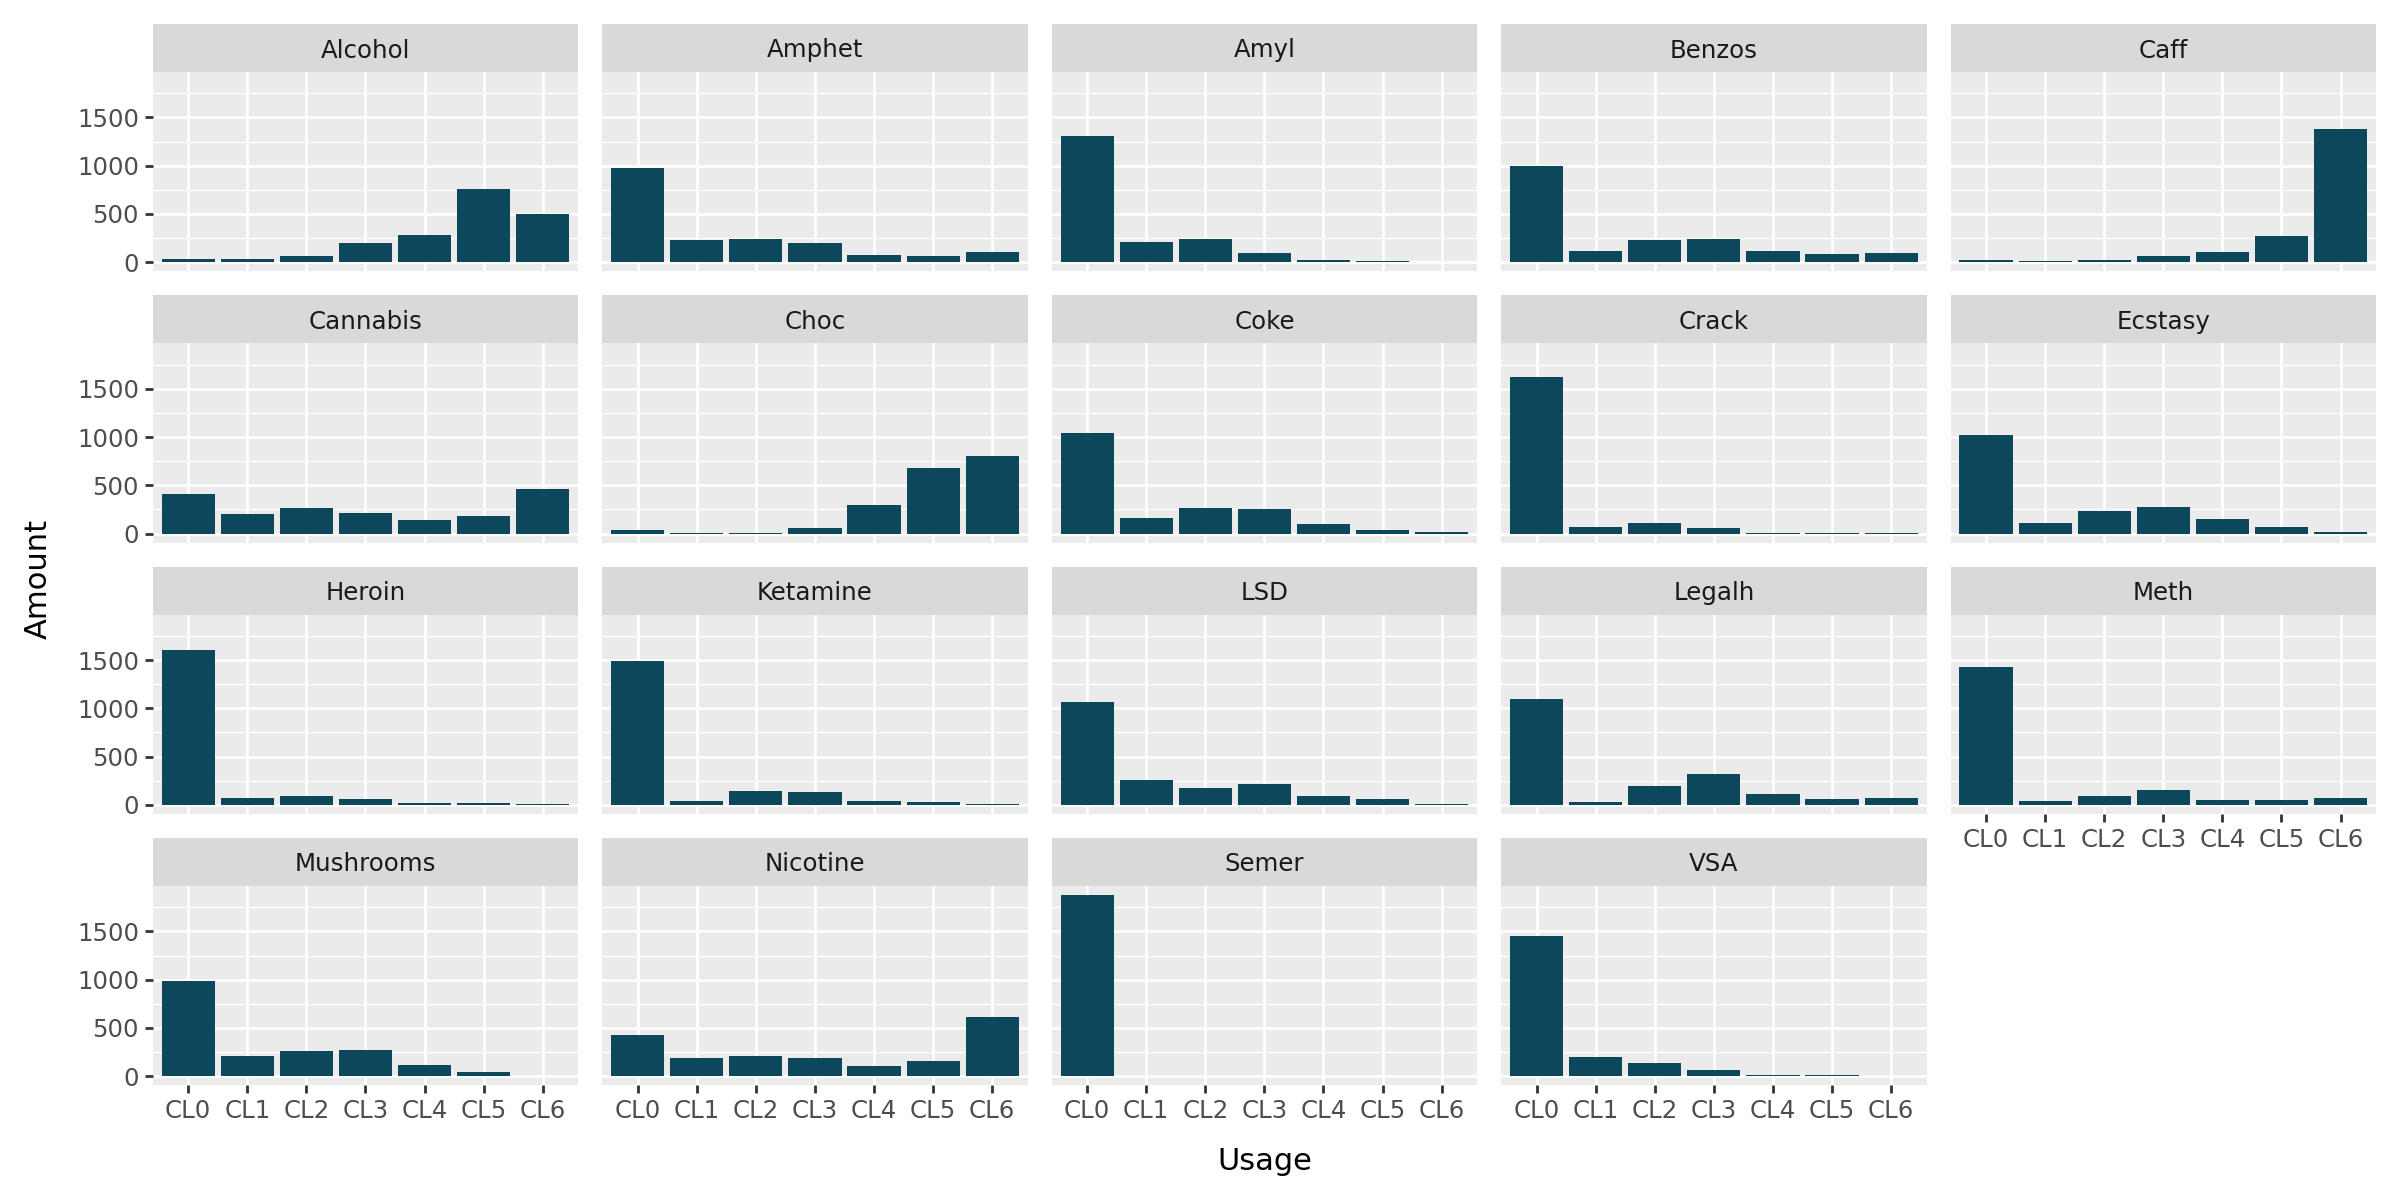

In [4]:
(
    pn.ggplot(drug_usage, pn.aes("Usage", "Amount", fill="Drug")) 
    + pn.geom_col(fill="#0C475B") 
    + pn.facet_wrap("Drug")
    + pn.theme(figure_size=(12, 6))
)

In [5]:
drug_users = drug_usage[drug_usage["Usage"] != "CL0"]
drug_users = drug_users.groupby(["Drug"], as_index=False)["Amount"].sum()
drug_users["Amount"] = drug_users["Amount"].astype(int)

# Sort values
drug_users = drug_users.assign(
    Drug=pd.Categorical(drug_users["Drug"], categories=drug_users.sort_values("Amount", ascending=False)["Drug"])
)

drug_users

,Drug,Amount
0,Alcohol,1851
1,Amphet,909
2,Amyl,580
3,Benzos,885
4,Caff,1858
5,Cannabis,1472
6,Choc,1853
7,Coke,847
8,Crack,258
9,Ecstasy,864


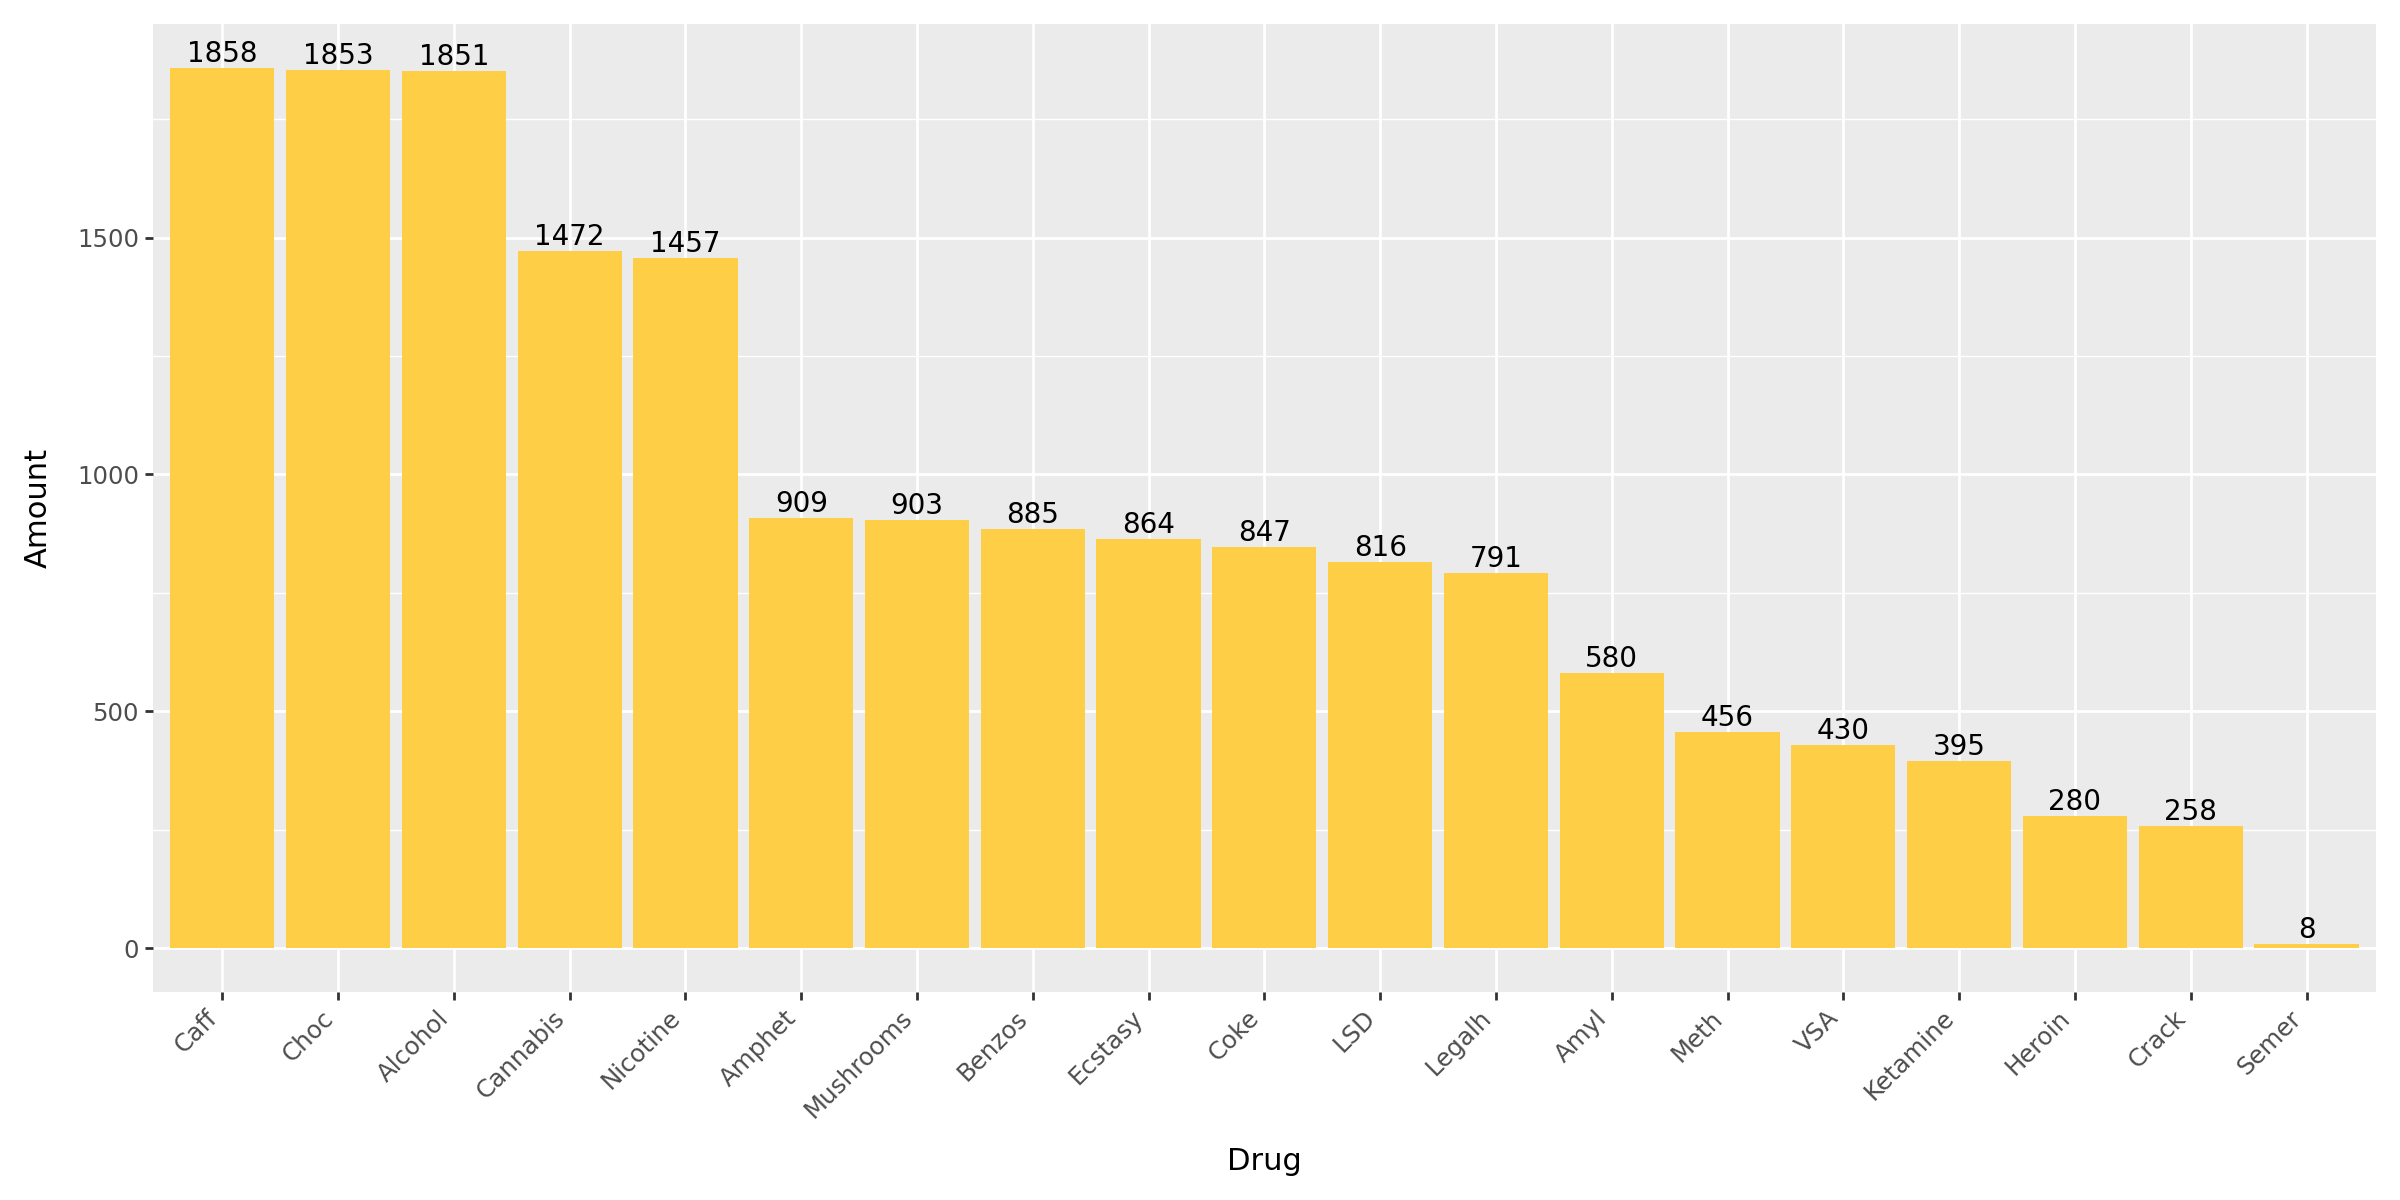

In [6]:
(
    pn.ggplot(drug_users, pn.aes("Drug", "Amount"))
    + pn.geom_col(fill="#ffce47")
    + pn.geom_text(pn.aes(label = "Amount"), size=10, va="bottom")
    + pn.labs(y="Amount")
    + pn.theme(figure_size=(12, 6), axis_text_x=pn.element_text(rotation=45, hjust=1))
)

Visualize the distribution of demographics

In [7]:
countries = human_readable_data.groupby("Country")["Country"].size().rename("Count").reset_index()

countries

,Country,Count
0,Australia,54
1,Canada,87
2,New Zealand,5
3,Other,118
4,Republic of Ireland,20
5,UK,1044
6,USA,557


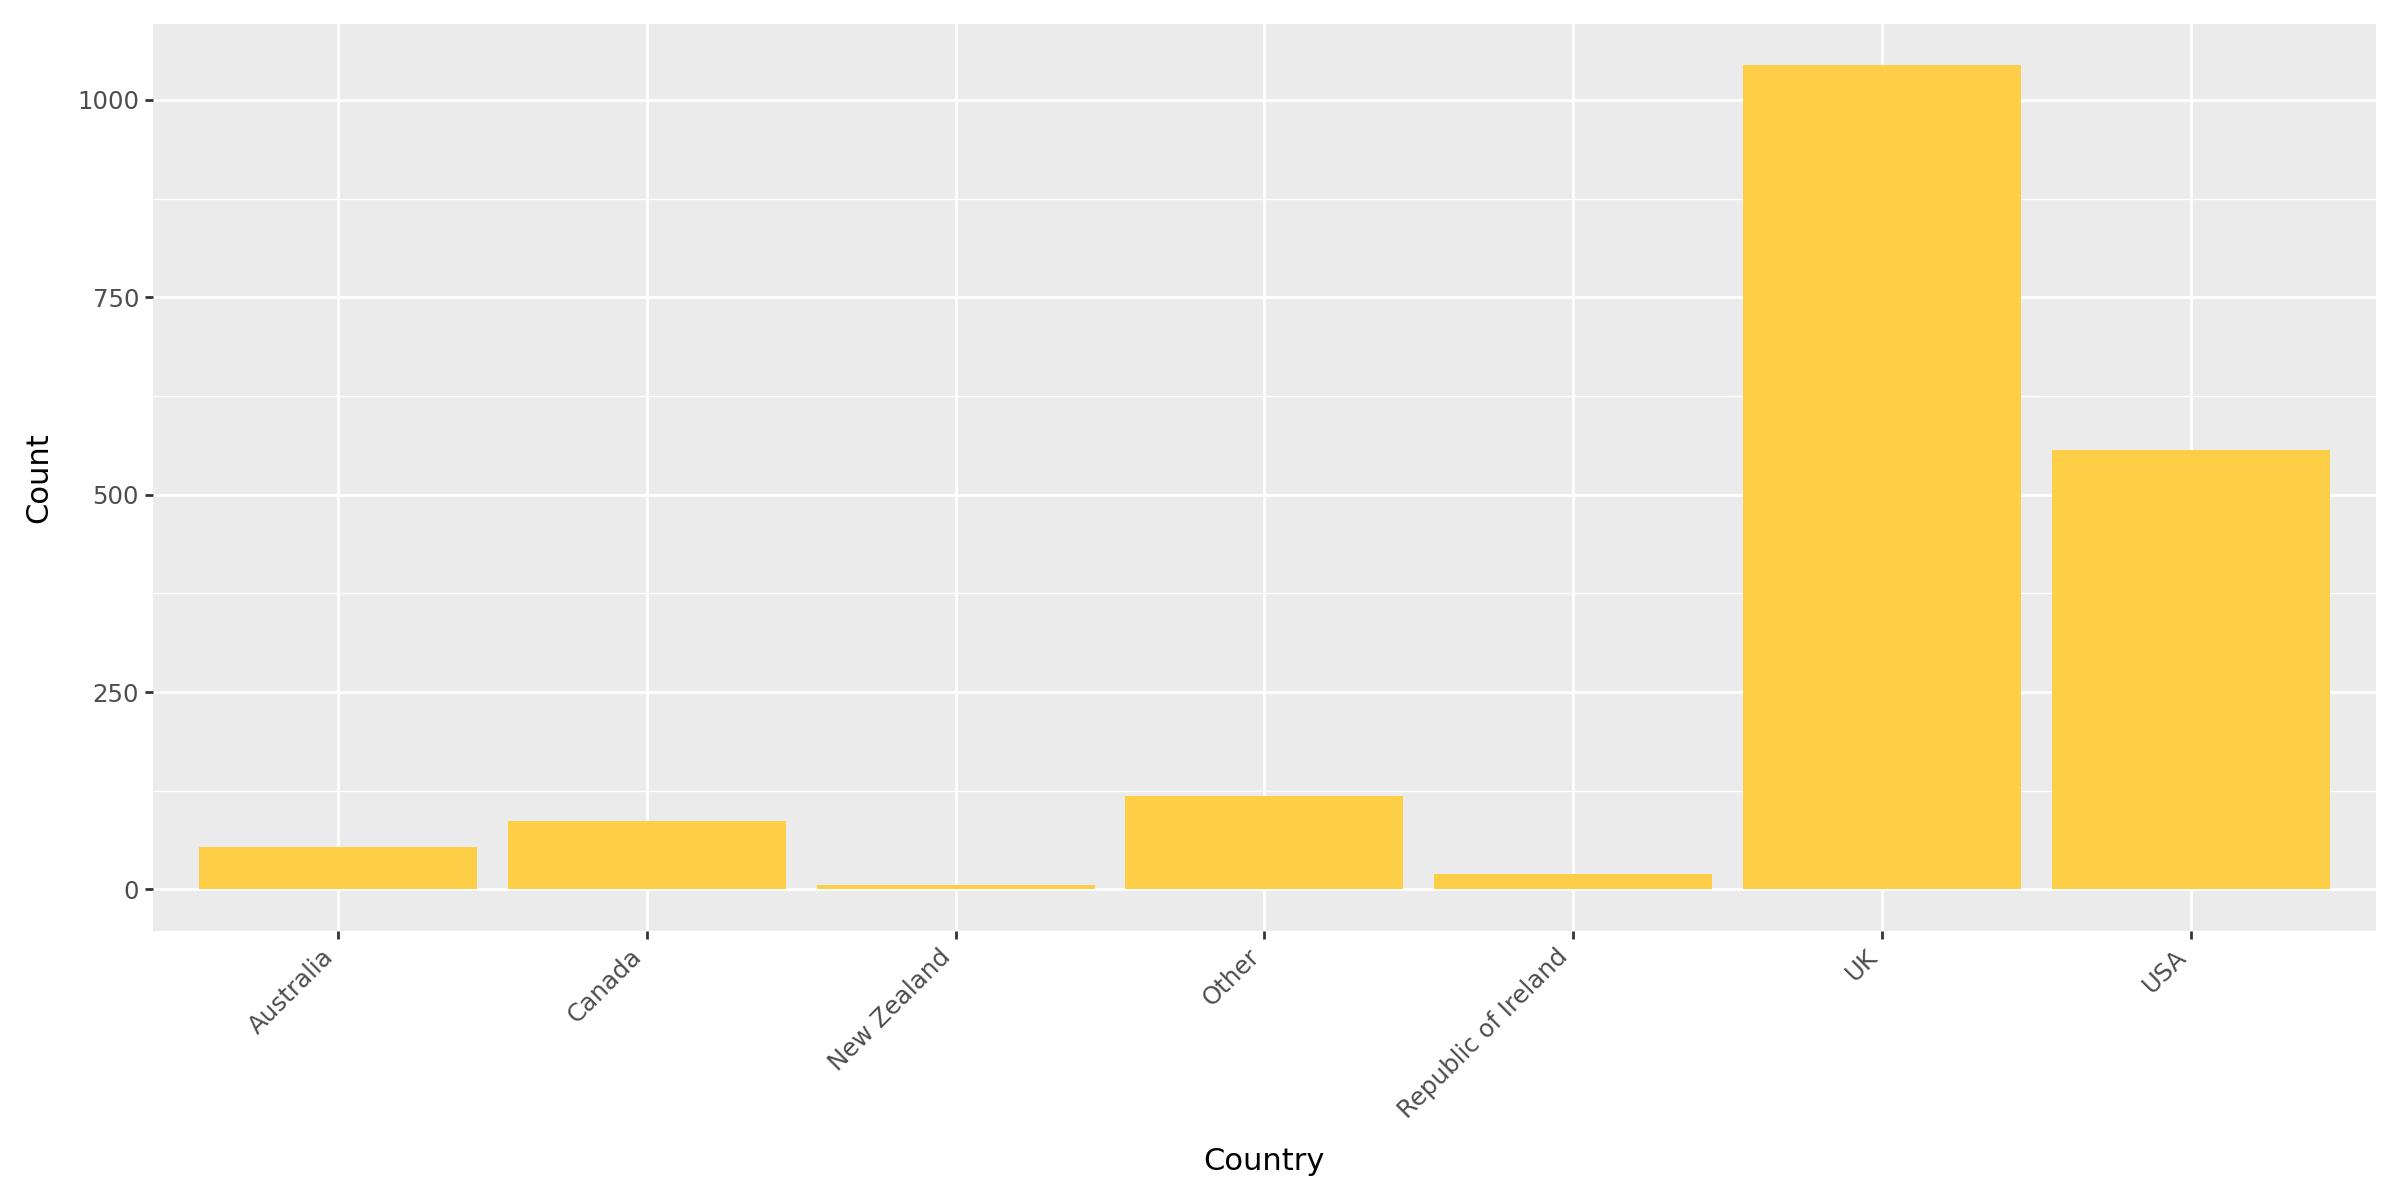

In [8]:
(
    pn.ggplot(countries, pn.aes("Country", "Count"))
    + pn.geom_col(fill="#ffce47")
    + pn.theme(figure_size=(12, 6), axis_text_x=pn.element_text(rotation=45, hjust=1))
)

In [9]:
countries.sort_values("Count", ascending=False)


,Country,Count
5,UK,1044
6,USA,557
3,Other,118
1,Canada,87
0,Australia,54
4,Republic of Ireland,20
2,New Zealand,5


In [10]:


# Ülemmäär, millest alates loeme neurootilisuse kõrgeks
high_N_threshold = human_readable_data["Nscore"].quantile(0.75)

# Ainult kõrge Nscore’iga inimesed
highN = human_readable_data[human_readable_data["Nscore"] >= high_N_threshold]

highN

,ID,Age,Gender,Education,Country,Ethnicity,Nscore,Escore,Oscore,Ascore,...,Ecstasy,Heroin,Ketamine,Legalh,LSD,Meth,Mushrooms,Nicotine,Semer,VSA
4,5,35-44,Female,Doctorate Degree,UK,White,43.0,28.0,43.0,41.0,...,Used over a Decade Ago,Never Used,Never Used,Used over a Decade Ago,Never Used,Never Used,Used in Last Decade,Used in Last Decade,Never Used,Never Used
8,9,35-44,Female,Professional Certificate/Diploma,Canada,White,42.0,55.0,39.0,48.0,...,Never Used,Never Used,Never Used,Never Used,Never Used,Never Used,Never Used,Used in Last Day,Never Used,Never Used
12,13,55-64,Female,University Degree,UK,White,56.0,41.0,49.0,32.0,...,Never Used,Never Used,Never Used,Never Used,Used over a Decade Ago,Used over a Decade Ago,Used over a Decade Ago,Used in Last Day,Never Used,Never Used
18,19,55-64,Male,University Degree,Australia,White,49.0,39.0,45.0,30.0,...,Used in Last Decade,Never Used,Never Used,Used in Last Decade,Used over a Decade Ago,Never Used,Used over a Decade Ago,Never Used,Never Used,Never Used
23,24,45-54,Male,Left School at 16 years,UK,White,51.0,16.0,37.0,45.0,...,Never Used,Used over a Decade Ago,Never Used,Never Used,Used over a Decade Ago,Never Used,Never Used,Used in Last Day,Never Used,Used over a Decade Ago
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1873,1877,18-24,Male,Left School at 17 years,USA,White,43.0,31.0,50.0,39.0,...,Used in Last Year,Used in Last Decade,Never Used,Used in Last Week,Used in Last Decade,Used in Last Decade,Used in Last Year,Used in Last Day,Never Used,Used in Last Decade
1874,1878,65+,Male,"Some College, No Certificate/Degree",USA,White,55.0,39.0,59.0,49.0,...,Never Used,Never Used,Never Used,Never Used,Used over a Decade Ago,Never Used,Used over a Decade Ago,Never Used,Never Used,Never Used
1877,1881,18-24,Male,Left School at 17 years,USA,White,50.0,26.0,42.0,31.0,...,Used in Last Decade,Used in Last Week,Never Used,Used in Last Decade,Never Used,Used in Last Day,Never Used,Used in Last Day,Never Used,Used in Last Decade
1882,1886,25-34,Female,University Degree,USA,White,47.0,30.0,37.0,31.0,...,Used in Last Month,Never Used,Used in Last Decade,Never Used,Used in Last Decade,Never Used,Used in Last Decade,Used in Last Day,Never Used,Never Used


In [11]:
ecstasy_pct = highN["Ecstasy"].value_counts(normalize=True) * 100
ecstasy_pct


Ecstasy
Never Used                46.741155
Used in Last Year         18.435754
Used in Last Decade       15.828678
Used in Last Month         8.007449
Used over a Decade Ago     6.145251
Used in Last Week          2.793296
Used in Last Day           2.048417
Name: proportion, dtype: float64

In [12]:
df["N_group"] = pd.qcut(
    df["Nscore"],
    q=4,
    labels=["1", "2", "3", "4"] #"x<25%", "25%<x<50%", "50%<x<75%", "75%<x"
)

ecstasy_df = pd.crosstab(
    df["N_group"],
    df["Ecstasy"],
    normalize="index"
) * 100
cols_order = [
    "Never Used",
    "Used over a Decade Ago",
    "Used in Last Decade",
    "Used in Last Year",
    "Used in Last Month",
    "Used in Last Week",
    "Used in Last Day",
]

ecstasy_df = ecstasy_df[cols_order]
ecstasy_df

Ecstasy,Never Used,Used over a Decade Ago,Used in Last Decade,Used in Last Year,Used in Last Month,Used in Last Week,Used in Last Day
N_group,,,,,,,
1,58.316633,6.613226,8.216433,11.623246,10.821643,3.406814,1.002004
2,59.375000,4.882812,11.718750,13.281250,6.640625,3.710938,0.390625
3,52.898551,6.280193,13.285024,16.425121,6.521739,3.381643,1.207729
4,45.000000,6.304348,16.956522,18.043478,8.913043,2.826087,1.956522


In [13]:
df

,ID,Age,Gender,Education,Country,Ethnicity,Nscore,Escore,Oscore,Ascore,...,Heroin,Ketamine,Legalh,LSD,Meth,Mushrooms,Nicotine,Semer,VSA,N_group
0,1,35-44,Female,Professional Certificate/Diploma,UK,Mixed-White/Asian,39.0,36.0,42.0,37.0,...,Never Used,Never Used,Never Used,Never Used,Never Used,Never Used,Used in Last Decade,Never Used,Never Used,3
1,2,25-34,Male,Doctorate Degree,UK,White,29.0,52.0,55.0,48.0,...,Never Used,Used in Last Decade,Never Used,Used in Last Decade,Used in Last Year,Never Used,Used in Last Month,Never Used,Never Used,1
2,3,35-44,Male,Professional Certificate/Diploma,UK,White,31.0,45.0,40.0,32.0,...,Never Used,Never Used,Never Used,Never Used,Never Used,Used over a Decade Ago,Never Used,Never Used,Never Used,2
3,4,18-24,Female,Master's Degree,UK,White,34.0,34.0,46.0,47.0,...,Never Used,Used in Last Decade,Never Used,Never Used,Never Used,Never Used,Used in Last Decade,Never Used,Never Used,2
4,5,35-44,Female,Doctorate Degree,UK,White,43.0,28.0,43.0,41.0,...,Never Used,Never Used,Used over a Decade Ago,Never Used,Never Used,Used in Last Decade,Used in Last Decade,Never Used,Never Used,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1880,1884,18-24,Female,"Some College, No Certificate/Degree",USA,White,25.0,51.0,57.0,48.0,...,Never Used,Never Used,Used in Last Year,Used in Last Year,Never Used,Never Used,Never Used,Never Used,Used in Last Week,1
1881,1885,18-24,Male,"Some College, No Certificate/Degree",USA,White,33.0,51.0,50.0,48.0,...,Never Used,Never Used,Used in Last Year,Used in Last Week,Used in Last Month,Used in Last Month,Used in Last Week,Never Used,Never Used,2
1882,1886,25-34,Female,University Degree,USA,White,47.0,30.0,37.0,31.0,...,Never Used,Used in Last Decade,Never Used,Used in Last Decade,Never Used,Used in Last Decade,Used in Last Day,Never Used,Never Used,4
1883,1887,18-24,Female,"Some College, No Certificate/Degree",USA,White,45.0,26.0,48.0,32.0,...,Never Used,Never Used,Used in Last Year,Used in Last Year,Never Used,Used in Last Year,Used in Last Month,Never Used,Never Used,4


In [14]:
df["N_group"].value_counts()

N_group
2    512
1    499
4    460
3    414
Name: count, dtype: int64

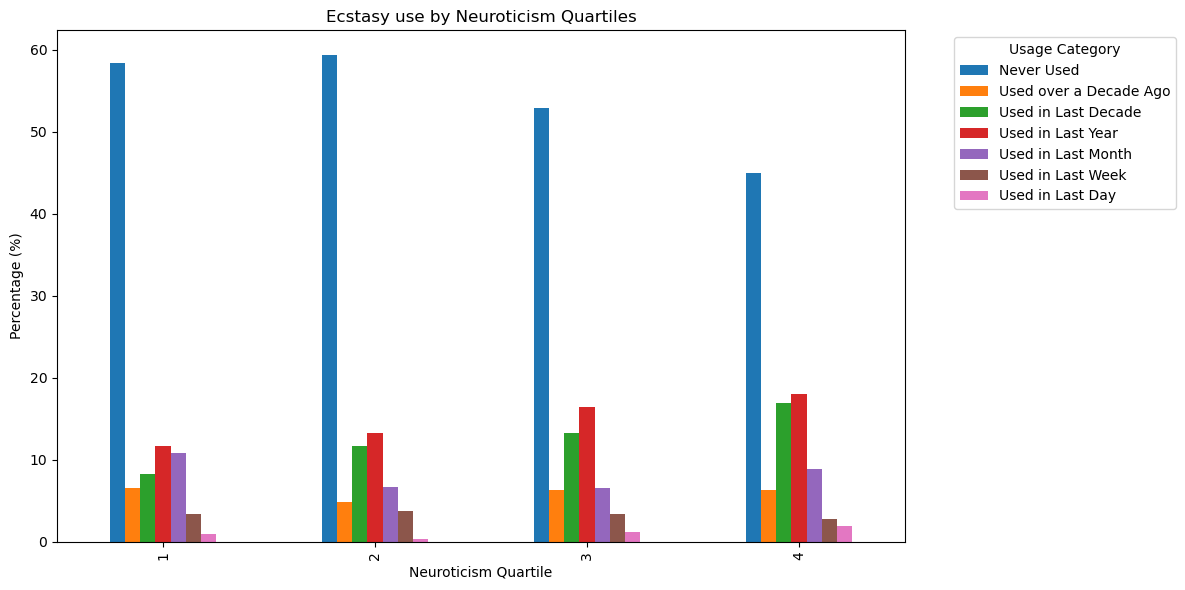

In [15]:
import matplotlib.pyplot as plt

ecstasy_df.plot(kind="bar", figsize=(12, 6))
plt.title("Ecstasy use by Neuroticism Quartiles")
plt.ylabel("Percentage (%)")
plt.xlabel("Neuroticism Quartile")
plt.legend(title="Usage Category", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


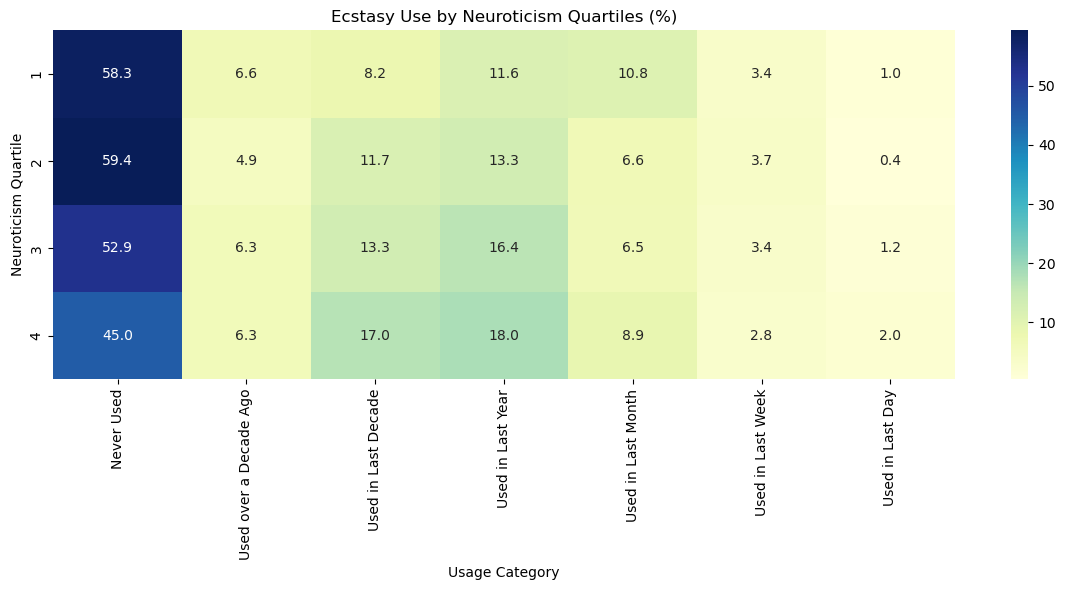

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.heatmap(
    ecstasy_df,
    annot=True,
    cmap="YlGnBu",
    fmt=".1f"
)

plt.title("Ecstasy Use by Neuroticism Quartiles (%)")
plt.ylabel("Neuroticism Quartile")
plt.xlabel("Usage Category")
plt.tight_layout()
plt.show()


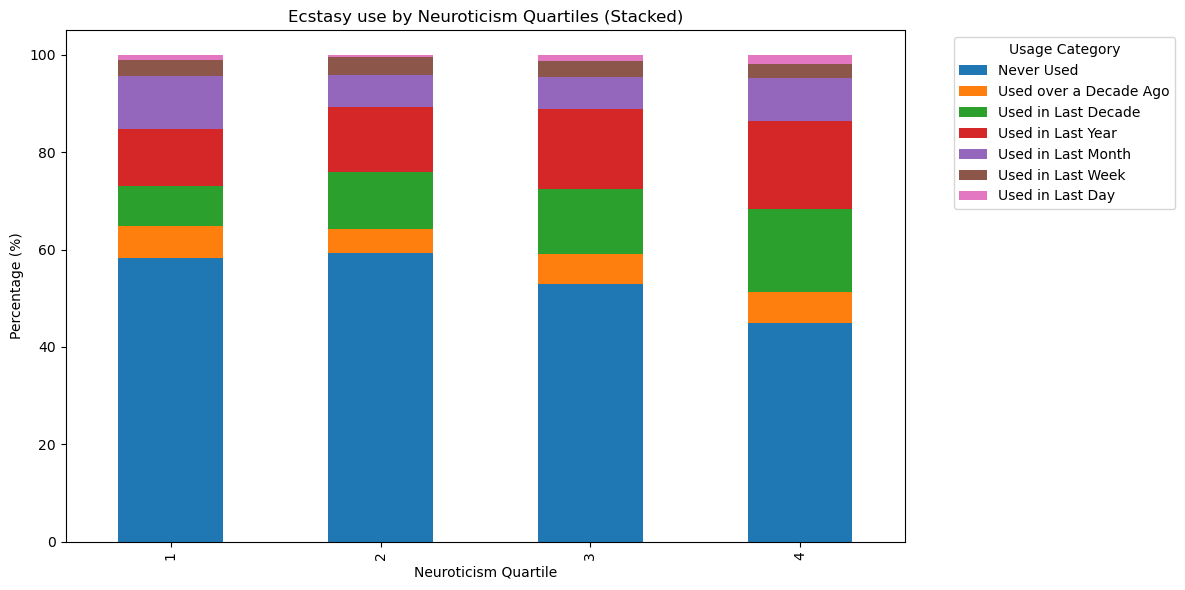

In [17]:
import matplotlib.pyplot as plt

ecstasy_df.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6)
)

plt.title("Ecstasy use by Neuroticism Quartiles (Stacked)")
plt.ylabel("Percentage (%)")
plt.xlabel("Neuroticism Quartile")
plt.legend(title="Usage Category", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

